In [14]:
import itertools
import math
import time
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

df1 = pd.read_csv("pairing_results_data1.csv")
df2 = pd.read_csv("pairing_results_data2.csv")
df3 = pd.read_csv("pairing_results_data3.csv")
df4 = pd.read_csv("pairing_results_data4.csv")
df5 = pd.read_csv("pairing_results_data5.csv")
df6 = pd.read_csv("pairing_results_data6.csv")

column_names  = ['NP1', 'NP2', 'NP3', 'NP4','NP5', 'NP6', 'NP7', 'NP8','NP9', 'NP10']
hf1 = pd.read_csv("heat_flux_v2/heatflux_all_data1_redo_v2.csv",header=None, names=column_names)
hf2 = pd.read_csv("heat_flux_v2/heatflux_all_data2_v2.csv",header=None, names=column_names)
hf3 = pd.read_csv("heat_flux_v2/heatflux_all_data3_v2.csv",header=None, names=column_names)
hf4 = pd.read_csv("heat_flux_v2/heatflux_all_data4_v2.csv",header=None, names=column_names)
hf5 = pd.read_csv("heat_flux_v2/heatflux_all_data5_v2.csv",header=None, names=column_names)
hf6 = pd.read_csv("heat_flux_v2/heatflux_all_data6_redo_v2.csv",header=None, names=column_names)



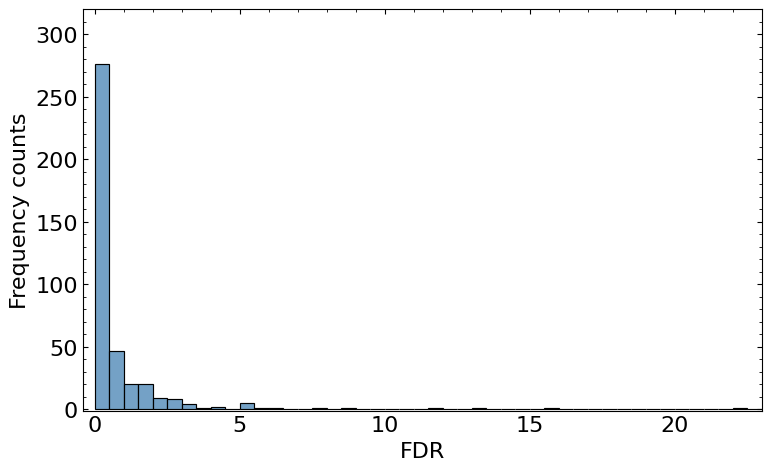

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Font Sizing
#SMALL_SIZE =12
#MEDIUM_SIZE = 15
#BIGGER_SIZE = 18
SMALL_SIZE =16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24




plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y label
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
####################################


datasets = [hf1, hf2, hf3, hf4, hf5, hf6]

labels = [f"input {i}" for i in range(1, 7)]
base_colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

# (Python is 0-indexed, so column 9 → index 8, column 10 → index 9)
output = pd.DataFrame({
    #f"col{i+1}": np.sqrt((df.iloc[:, 8] - df.iloc[:, 9])**2)*6.95
    f"col{i+1}": (df.iloc[:, 8] - df.iloc[:, 9])*6.95
    for i, df in enumerate(datasets)
})

# Compare first 3 columns (0,1,2) with next 3 columns (3,4,5)
left = output.iloc[:, 0:3]
right = output.iloc[:, 3:6]

# Compute mean and variance per row for each 3D group
mu_A = output.iloc[:, 0:3].mean(axis=1)
mu_B = output.iloc[:, 3:6].mean(axis=1)
var_A = output.iloc[:, 0:3].var(axis=1, ddof=1)
var_B = output.iloc[:, 3:6].var(axis=1, ddof=1)


# Compute Fisher’s Discriminant Ratio (FDR) for each row 
output["FDR_distance"] = (mu_A - mu_B) ** 2 / (var_A + var_B + 1e-8)


# Also compute centroid (mean) distance per row for reference
output["centroid_distance"] = (mu_A - mu_B)*6.95

# 1. Combine
combined = pd.concat([df1["pairing_num"],
                      #output["centroid_distance"],
                      output["FDR_distance"]], axis=1)


# 2. Sort by FDR_distance
combined_sorted = combined.sort_values(by="FDR_distance", ascending=False)

# Extract FDR_distance column and round to 3 decimal places
y_values = output["FDR_distance"]
bin_width3 = 0.5
bins3 = np.arange(0, 24 + bin_width3, bin_width3)
# Plot the distribution of y
fig = plt.figure(figsize=(8, 5))
sns.histplot(y_values, kde=False, bins=bins3, color='steelblue')
#plt.title(f"Distribution of |J9-J10| FDR_distance")
plt.xlabel("FDR")
plt.ylabel("Frequency counts")
plt.xlim((-0.4, 23))
plt.ylim((-1, 320))
plt.minorticks_on()
plt.tick_params(axis='both',bottom=False,top=True,left=True,right=True,direction='in',which='both',labelsize=16)
plt.tight_layout()
#fig.savefig(f"SI_Round1_FDR.pdf", format="pdf")
plt.show()


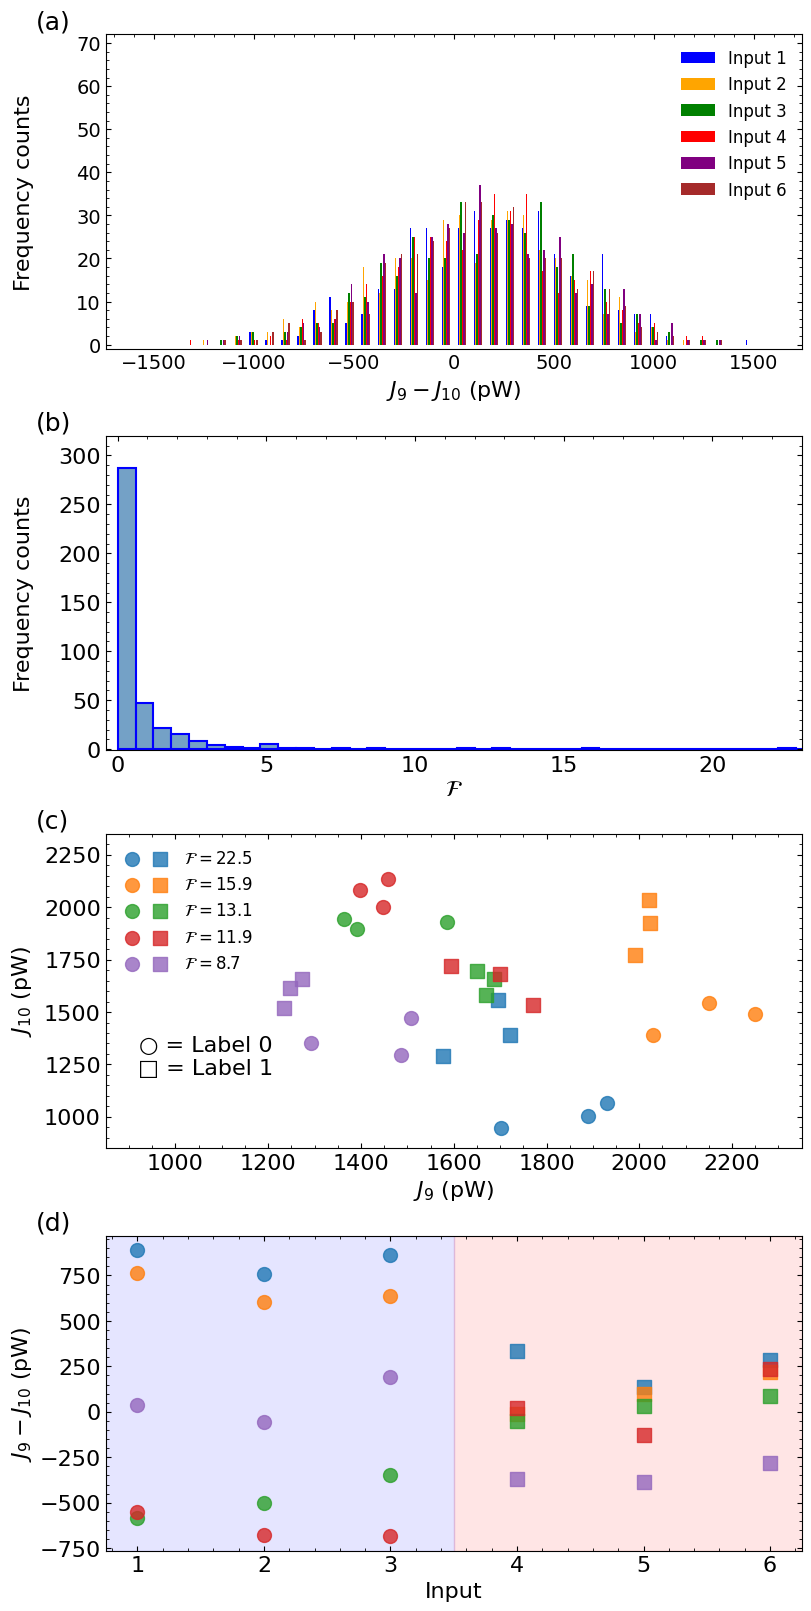

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# -------------------------------------------------------------------
# Font settings
# -------------------------------------------------------------------
SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('axes', labelsize=SMALL_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=12)
plt.rc('figure', titlesize=BIGGER_SIZE)

# -------------------------------------------------------------------
# Data preparation
# -------------------------------------------------------------------
top_5 = output.sort_values('FDR_distance', ascending=False).head(5)
top_5_indices = top_5.index

columns_to_plot = ['col1', 'col2', 'col3', 'col4', 'col5', 'col6']
columns_group1 = ['col1', 'col2', 'col3']
columns_group2 = ['col4', 'col5', 'col6']

x_labels = ['1', '2', '3', '4', '5', '6']
x = np.arange(len(x_labels))

tab_colors = plt.cm.tab10.colors
base_colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

# J9 and J10 values
output_J9 = pd.DataFrame({
    f"col{i+1}": data.iloc[:, 8] * 6.95
    for i, data in enumerate(datasets)
})

output_J10 = pd.DataFrame({
    f"col{i+1}": data.iloc[:, 9] * 6.95
    for i, data in enumerate(datasets)
})

# J9 - J10 values for histogram
j_difference_output = pd.DataFrame({
    f"col{i+1}": (data.iloc[:, 8] - data.iloc[:, 9]) * 6.95
    for i, data in enumerate(datasets)
})

# FDR data
fdr_data = pd.DataFrame({
    "pairing_num": df1["pairing_num"].to_numpy(),
    "FDR_distance": output["FDR_distance"].to_numpy(),
})

# -------------------------------------------------------------------
# Combined figure:
# (a), (b): second/original histogram figure shown first
# (c), (d): first/original scatter figure shown afterward
# -------------------------------------------------------------------
fig, (ax_a, ax_b, ax_c, ax_d) = plt.subplots(
    4, 1,
    figsize=(8, 16),
    constrained_layout=True
)

# ===================================================================
# (a) Histogram of J9 - J10 for six inputs
# ===================================================================
labels = [f"Input {i}" for i in range(1, 7)]

bin_edges = np.arange(-1600, 1600 + 80, 80)
bar_width = 7
n_sets = 6

for i, (label, base_color) in enumerate(zip(labels, base_colors)):
    counts, _ = np.histogram(
        j_difference_output[f"col{i+1}"],
        bins=bin_edges
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    offset = (i - (n_sets - 1) / 2) * bar_width

    ax_a.bar(
        bin_centers + offset,
        counts,
        width=bar_width,
        label=label,
        color=base_color,
        linewidth=2
    )

ax_a.set_xlabel(r'$J_{9}-J_{10}$ (pW)')
ax_a.set_ylabel('Frequency counts')
ax_a.set_ylim(-1, 72)
ax_a.minorticks_on()
ax_a.tick_params(
    axis='both', bottom=False, top=True, left=True, right=True,
    direction='in', which='both', labelsize=14
)
ax_a.legend(framealpha=0.0, loc='upper right', ncol=1)
ax_a.text(
    -0.1, 1.08, '(a)',
    transform=ax_a.transAxes,
    fontsize=18, va='top', ha='left'
)

# ===================================================================
# (b) Histogram of FDR distance
# ===================================================================
y_values = fdr_data["FDR_distance"].dropna()

bin_width_fdr = 0.6
bins_fdr = np.arange(0, 24 + bin_width_fdr, bin_width_fdr)

sns.histplot(
    y_values,
    kde=False,
    bins=bins_fdr,
    color='steelblue',
    edgecolor='blue',
    linewidth=1.5,
    ax=ax_b
)

ax_b.set_xlabel(r'$\mathcal{F}$', fontfamily='STIXGeneral')
ax_b.set_ylabel('Frequency counts')
ax_b.set_xlim(-0.4, 23)
ax_b.set_ylim(-1, 320)
ax_b.minorticks_on()
ax_b.tick_params(
    axis='both', bottom=False, top=True, left=True, right=True,
    direction='in', which='both', labelsize=16
)
ax_b.text(
    -0.1, 1.08, '(b)',
    transform=ax_b.transAxes,
    fontsize=18, va='top', ha='left'
)

# ===================================================================
# (c) Scatter plot: J9 vs. J10
# ===================================================================
legend_handles = []
legend_labels = []

for i, idx in enumerate(top_5_indices):
    fdr_value = top_5.loc[idx, 'FDR_distance']

    # Label 0: circles
    j9_g1 = output_J9.loc[idx, columns_group1]
    j10_g1 = output_J10.loc[idx, columns_group1]

    scatter_circle = ax_c.scatter(
        j9_g1, j10_g1,
        s=100,
        color=tab_colors[i],
        marker='o',
        alpha=0.8
    )

    # Label 1: squares
    j9_g2 = output_J9.loc[idx, columns_group2]
    j10_g2 = output_J10.loc[idx, columns_group2]

    scatter_square = ax_c.scatter(
        j9_g2, j10_g2,
        s=100,
        color=tab_colors[i],
        marker='s',
        alpha=0.8
    )

    legend_handles.append((scatter_circle, scatter_square))
    legend_labels.append(fr'$\mathcal{{F}}={fdr_value:.1f}$')

ax_c.text(
    0.24, 0.36,
    '○ = Label 0\n□ = Label 1',
    transform=ax_c.transAxes,
    fontsize=16,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.0)
)

ax_c.set_xlabel(r'$J_{9}$ (pW)')
ax_c.set_ylabel(r'$J_{10}$ (pW)')
ax_c.set_xlim(850, 2350)
ax_c.set_ylim(850, 2350)
ax_c.minorticks_on()
ax_c.tick_params(
    axis='both', bottom=True, top=True, left=True, right=True,
    direction='in', which='both', labelsize=16
)

ax_c.legend(
    handles=legend_handles,
    labels=legend_labels,
    numpoints=1,
    handlelength=3,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    framealpha=0.0,
    loc='upper left',
    ncol=1
)

ax_c.text(
    -0.1, 1.08, '(c)',
    transform=ax_c.transAxes,
    fontsize=18, va='top', ha='left'
)

# ===================================================================
# (d) Top-five FDR settings across the six inputs
# ===================================================================
ax_d.axvspan(-0.5, 2.5, alpha=0.1, color='blue', zorder=0)
ax_d.axvspan(2.5, 5.5, alpha=0.1, color='red', zorder=0)

for i, (idx, row) in enumerate(top_5.iterrows()):
    y_values = row[columns_to_plot]
    color = tab_colors[i % len(tab_colors)]

    # Label 0: circles
    ax_d.scatter(
        x[:3],
        y_values.iloc[:3],
        s=100,
        alpha=0.8,
        marker='o',
        color=color,
        zorder=3
    )

    # Label 1: squares
    ax_d.scatter(
        x[3:],
        y_values.iloc[3:],
        s=100,
        alpha=0.8,
        marker='s',
        color=color,
        zorder=3
    )

ax_d.set_xlabel('Input')
ax_d.set_ylabel(r'$J_{9}-J_{10}$ (pW)')
ax_d.set_xticks(x)
ax_d.set_xticklabels(x_labels)
ax_d.minorticks_on()
ax_d.tick_params(
    axis='both', bottom=True, top=True, left=True, right=True,
    direction='in', which='both', labelsize=16
)

ax_d.text(
    -0.1, 1.08, '(d)',
    transform=ax_d.transAxes,
    fontsize=18, va='top', ha='left'
)

# Align y-axis labels and save/show
fig.align_ylabels([ax_a, ax_b, ax_c, ax_d])

fig.savefig(f"submit2_round1_J9_minus_J10_FDR.pdf", format="pdf", bbox_inches="tight")
plt.show()